# Tabular-Only Logistic Regression — Mixed-All Multimodal Dataset

Logistic Regression on transaction features only from `mm_*_mixed_all_group_test.csv`.

### Purpose
Tabular-only lower bound for the multimodal chapter. Directly comparable to
notebook 11 (full PaySim LR) in methodology.

### Two parts — mirrors notebook 12 structure
**Part A — Raw features** (7 transaction variables)
**Part B — Engineered features** (adds 5 balance-delta/ratio features)

### Three imbalance variants per part — mirrors notebook 11
1. None — no correction
2. Class weights — `class_weight="balanced"`
3. SMOTE — oversample minority class

Note: SMOTE is valid here for tabular-only models. For image/multimodal
models, SMOTE is replaced by WeightedRandomSampler.

### Feature note
`tab_isFraud` is **excluded** — `final_label` is derived from it (leakage).
`tab_isFlaggedFraud` is **included** — it is a PaySim rule-based flag.

## 0 · Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from tabular_baseline_utils import (
    build_preprocessor, build_logreg_pipeline, fit_model,
    evaluate_model, search_thresholds, compute_cost_table,
    evaluate_with_threshold, save_experiment_outputs,
    compute_expected_cost_from_cm,
)

PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_ROOT = PROJECT_ROOT / "notebook" / "results" / "mm_tabular_logreg"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_ROOT)

Results dir: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg


## 1 · Load data

In [2]:
train_df = pd.read_csv(DATA_DIR / "mm_train_mixed_all_group_test.csv")
val_df   = pd.read_csv(DATA_DIR / "mm_val_mixed_all_group_test.csv")
test_df  = pd.read_csv(DATA_DIR / "mm_test_mixed_all_group_test.csv")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 7,182 | Val: 1,508 | Test: 1,474


## 2 · Feature definitions & engineering

In [3]:
from mm_tabular_utils import (
    TARGET_COL, RAW_COLS, FE_COLS,
    NUMERIC_RAW, NUMERIC_FE, CAT_COLS,
    engineer_features, validate_features, print_feature_summary,
    FORBIDDEN_COLS,
)

print_feature_summary()

# Validate — raises if any forbidden column slips through
validate_features(RAW_COLS)
validate_features(FE_COLS)

Raw features  (8): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_type']
FE  features  (13): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed', 'tab_type']

Forbidden (excluded): ['combo_type', 'final_label', 'img_final_label', 'img_image_class', 'img_image_path', 'img_original_label', 'img_source_dataset', 'img_split', 'mm_id', 'split', 'tab_final_label', 'tab_isFraud']
Feature validation passed — 8 features, no leakage.
Feature validation passed — 13 features, no leakage.


## 3 · Imbalance analysis

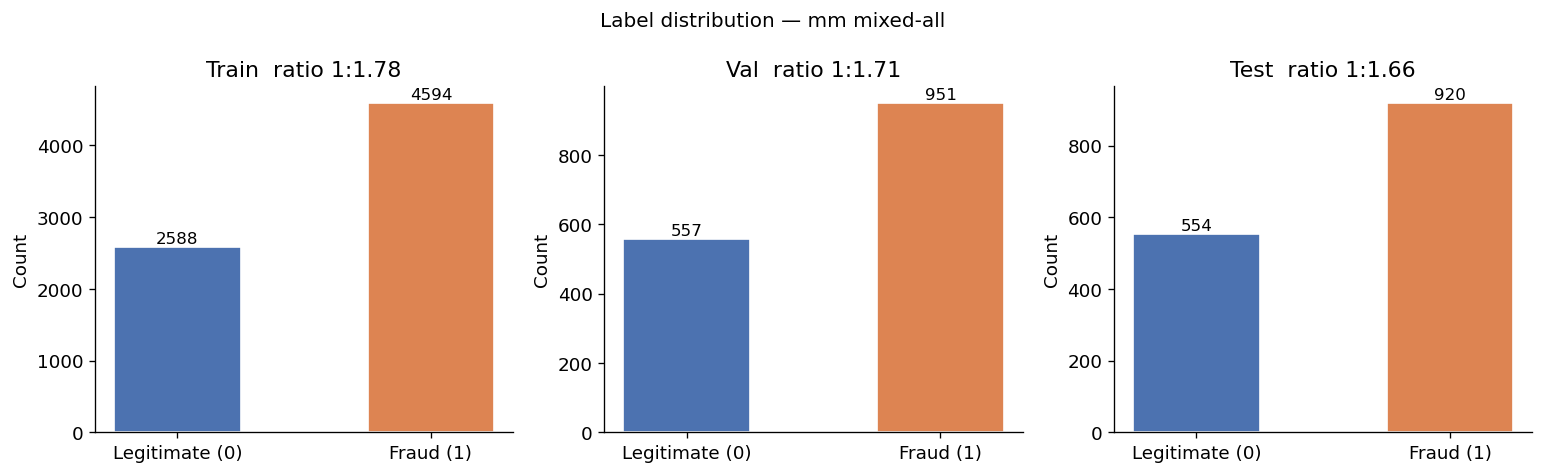

Label imbalance: 2588 legitimate vs 4594 fraud  (ratio 1:1.78)

Imbalance strategies to test:
  1. None         — no correction, raw training
  2. Class weight — balanced class_weight in classifier
  3. SMOTE        — oversample minority class (tabular only, not images)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, df) in zip(axes, [("Train",train_df),("Val",val_df),("Test",test_df)]):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0)/max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}")
    ax.set_ylabel("Count"); ax.spines[["top","right"]].set_visible(False)
fig.suptitle("Label distribution — mm mixed-all", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_ROOT / "label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

n0 = (train_df[TARGET_COL]==0).sum()
n1 = (train_df[TARGET_COL]==1).sum()
print(f"Label imbalance: {n0} legitimate vs {n1} fraud  (ratio 1:{n1/n0:.2f})")
print(f"\nImbalance strategies to test:")
print("  1. None         — no correction, raw training")
print("  2. Class weight — balanced class_weight in classifier")
print("  3. SMOTE        — oversample minority class (tabular only, not images)")

## 4 · Experiment helper

In [5]:
def run_lr_experiment(label, results_dir, X_tr, y_tr, X_v, y_v, X_te, y_te,
                      numeric_cols, imbalance_method):
    results_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*55}\n{label}\n{'='*55}")

    preprocessor = build_preprocessor(numeric_cols, CAT_COLS)
    model = build_logreg_pipeline(preprocessor, imbalance_method=imbalance_method)
    model = fit_model(model, X_tr, y_tr)

    val_metrics, val_cm   = evaluate_model(model, X_v, y_v, f"val_{label}")
    threshold_df          = search_thresholds(model, X_v, y_v)
    cost_df               = compute_cost_table(threshold_df, y_v)
    best_t                = float(cost_df.iloc[0]["threshold"])
    tuned_metrics, tun_cm = evaluate_with_threshold(model, X_te, y_te, best_t)

    save_experiment_outputs(
        results_dir=results_dir, model=model,
        val_metrics=val_metrics, test_metrics=val_metrics,
        val_cm=val_cm, test_cm=val_cm,
        threshold_results=threshold_df, cost_df=cost_df,
        tuned_metrics=tuned_metrics, tuned_cm=tun_cm,
        prefix=label,
    )
    print(f"  Best threshold: {best_t:.2f}")
    print(f"  Tuned F1:       {tuned_metrics['f1']:.4f}")
    return {"label":label, "model":model, "val_metrics":val_metrics,
            "tuned_metrics":tuned_metrics, "tuned_cm":tun_cm,
            "best_threshold":best_t}

---
## Part A — Raw features
Same 7 transaction variables as notebook 11.

In [6]:
X_train_raw = train_df[RAW_COLS]; y_train = train_df[TARGET_COL]
X_val_raw   = val_df[RAW_COLS];   y_val   = val_df[TARGET_COL]
X_test_raw  = test_df[RAW_COLS];  y_test  = test_df[TARGET_COL]

ra_none = run_lr_experiment("A_none",    RESULTS_ROOT/"A_none",    X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test, NUMERIC_RAW, "none")
ra_cw   = run_lr_experiment("A_weight",  RESULTS_ROOT/"A_weight",  X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test, NUMERIC_RAW, "class_weight")
ra_sm   = run_lr_experiment("A_smote",   RESULTS_ROOT/"A_smote",   X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test, NUMERIC_RAW, "smote")


A_none

=== VAL_A_NONE ===
accuracy: 0.680371
precision: 0.728780
recall: 0.785489
f1: 0.756073
roc_auc: 0.767932
pr_auc: 0.880144

Confusion matrix:
[[279 278]
 [204 747]]

Classification report:
              precision    recall  f1-score   support

           0     0.5776    0.5009    0.5365       557
           1     0.7288    0.7855    0.7561       951

    accuracy                         0.6804      1508
   macro avg     0.6532    0.6432    0.6463      1508
weighted avg     0.6730    0.6804    0.6750      1508


Tuned threshold: 0.1
Precision: 0.6245756958587916
Recall: 1.0
F1: 0.768909318846636

Confusion matrix:
[[  1 553]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.0018    0.0036       554
           1     0.6246    1.0000    0.7689       920

    accuracy                         0.6248      1474
   macro avg     0.8123    0.5009    0.3863      1474
weighted avg     0.7657    0.6248    0.4813      14

---
## Part B — Engineered features
Adds 5 balance-delta/ratio features. Same as notebook 12 Part A and multimodal experiments C/D.

In [8]:
train_fe = engineer_features(train_df)
val_fe   = engineer_features(val_df)
test_fe  = engineer_features(test_df)

X_train_fe = train_fe[FE_COLS]; X_val_fe = val_fe[FE_COLS]; X_test_fe = test_fe[FE_COLS]

rb_none = run_lr_experiment("B_none",   RESULTS_ROOT/"B_none",   X_train_fe, y_train, X_val_fe, y_val, X_test_fe, y_test, NUMERIC_FE, "none")
rb_cw   = run_lr_experiment("B_weight", RESULTS_ROOT/"B_weight", X_train_fe, y_train, X_val_fe, y_val, X_test_fe, y_test, NUMERIC_FE, "class_weight")
rb_sm   = run_lr_experiment("B_smote",  RESULTS_ROOT/"B_smote",  X_train_fe, y_train, X_val_fe, y_val, X_test_fe, y_test, NUMERIC_FE, "smote")


B_none

=== VAL_B_NONE ===
accuracy: 0.682361
precision: 0.732283
recall: 0.782334
f1: 0.756482
roc_auc: 0.776748
pr_auc: 0.887079

Confusion matrix:
[[285 272]
 [207 744]]

Classification report:
              precision    recall  f1-score   support

           0     0.5793    0.5117    0.5434       557
           1     0.7323    0.7823    0.7565       951

    accuracy                         0.6824      1508
   macro avg     0.6558    0.6470    0.6499      1508
weighted avg     0.6758    0.6824    0.6778      1508


Tuned threshold: 0.1
Precision: 0.625
Recall: 1.0
F1: 0.7692307692307693

Confusion matrix:
[[  2 552]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.0036    0.0072       554
           1     0.6250    1.0000    0.7692       920

    accuracy                         0.6255      1474
   macro avg     0.8125    0.5018    0.3882      1474
weighted avg     0.7659    0.6255    0.4828      1474

  Best t

---
## Comparison — all six variants

In [9]:
all_results = [ra_none, ra_cw, ra_sm, rb_none, rb_cw, rb_sm]

comparison_df = pd.DataFrame([
    {"experiment": r["label"],
     "features":   "Raw" if r["label"].startswith("A") else "Engineered",
     "imbalance":  r["label"].split("_")[1],
     "val_f1":     r["val_metrics"]["f1"],
     "val_roc_auc":r["val_metrics"]["roc_auc"],
     "val_pr_auc": r["val_metrics"]["pr_auc"],
     "best_threshold": r["best_threshold"],
     "tuned_f1":   r["tuned_metrics"]["f1"],
     "tuned_recall":r["tuned_metrics"]["recall"],
     "tuned_precision":r["tuned_metrics"]["precision"],
     "tuned_cost": compute_expected_cost_from_cm(r["tuned_cm"])["expected_cost"]}
    for r in all_results
])
comparison_df.to_csv(RESULTS_ROOT / "comparison.csv", index=False)
display(comparison_df.sort_values("tuned_f1", ascending=False).round(4))

,experiment,features,imbalance,val_f1,val_roc_auc,val_pr_auc,best_threshold,tuned_f1,tuned_recall,tuned_precision,tuned_cost
5,B_smote,Engineered,smote,0.7314,0.7775,0.8880,0.1,0.7696,0.9967,0.6268,423000
1,A_weight,Raw,weight,0.7259,0.7694,0.8814,0.1,0.7692,1.0000,0.6250,276000
3,B_none,Engineered,none,0.7565,0.7767,0.8871,0.1,0.7692,1.0000,0.6250,276000
2,A_smote,Raw,smote,0.7252,0.7697,0.8819,0.1,0.7692,1.0000,0.6250,276000
4,B_weight,Engineered,weight,0.7283,0.7778,0.8880,0.1,0.7690,0.9967,0.6259,424000
0,A_none,Raw,none,0.7561,0.7679,0.8801,0.1,0.7689,1.0000,0.6246,276500


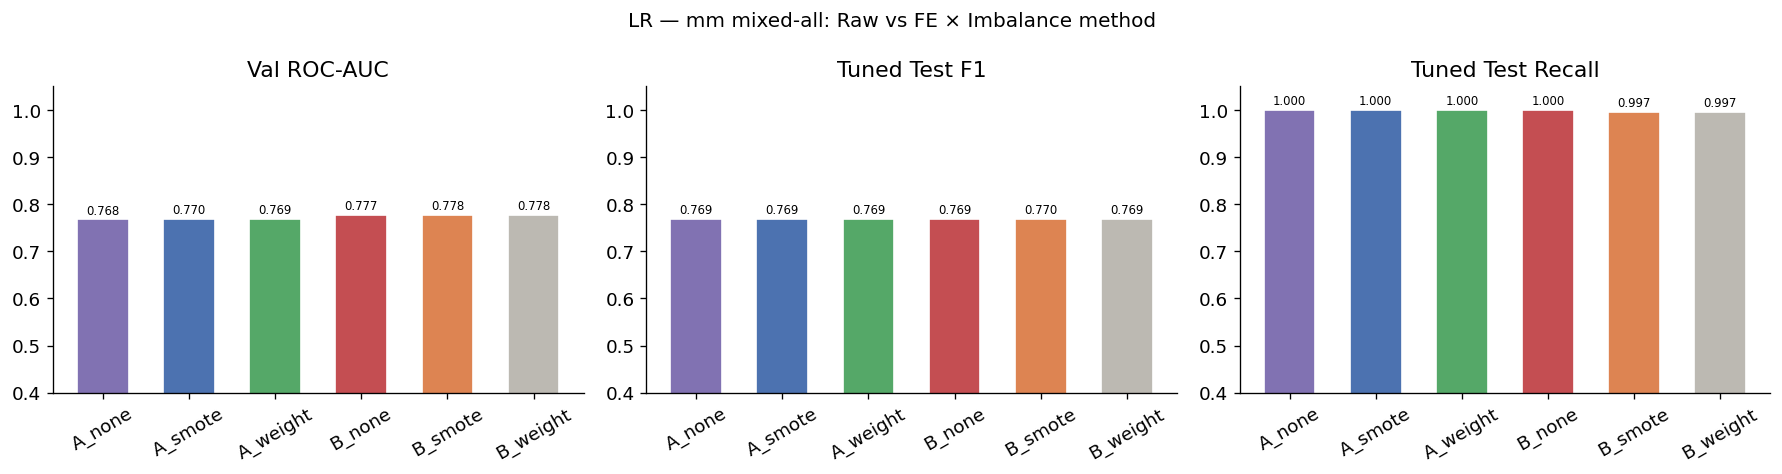

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score
colours = ["#4C72B0","#4C72B0","#4C72B0","#DD8452","#DD8452","#DD8452"]
styles  = ["-","--",":"] * 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_all = [(ra_none, ra_cw, ra_sm, "Raw"), (rb_none, rb_cw, rb_sm, "Engineered")]

metrics_plot = ["val_roc_auc","tuned_f1","tuned_recall"]
titles       = ["Val ROC-AUC","Tuned Test F1","Tuned Test Recall"]

x = np.arange(6); width = 0.6
bar_colours = ["#8172B2","#4C72B0","#55A868","#C44E52","#DD8452","#BCB9B2"]

for ax, metric, title in zip(axes, metrics_plot, titles):
    vals = comparison_df.sort_values("experiment")[metric].values
    bars = ax.bar(comparison_df.sort_values("experiment")["experiment"],
                  vals, color=bar_colours, edgecolor="white", width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(title); ax.set_ylim(0.4, 1.05)
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("LR — mm mixed-all: Raw vs FE × Imbalance method", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_ROOT / "comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Final summary

In [11]:
best = comparison_df.sort_values("tuned_f1", ascending=False).iloc[0]
print(f"Best LR variant: {best['experiment']}")
print(f"  Features  : {best['features']}")
print(f"  Imbalance : {best['imbalance']}")
print(f"  Threshold : {best['best_threshold']:.2f}")
print(f"  F1        : {best['tuned_f1']:.4f}")
print(f"  Recall    : {best['tuned_recall']:.4f}")
print(f"  ROC-AUC   : {best['val_roc_auc']:.4f}")
print(f"\nAll results saved to: {RESULTS_ROOT}")

Best LR variant: B_smote
  Features  : Engineered
  Imbalance : smote
  Threshold : 0.10
  F1        : 0.7696
  Recall    : 0.9967
  ROC-AUC   : 0.7775

All results saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg
